##Introduction

Python is a great general-purpose programming language on its own, but with the help of a few popular libraries (numpy, scipy, matplotlib) it becomes a powerful environment for scientific computing.

We expect that many of you will have some experience with Python; for the rest of you, this section will serve as a quick crash course both on the Python programming language and on the use of Python for scientific computing.

In this tutorial, we will cover:

* Basic Python: Basic data types (Containers, Lists, Dictionaries, Sets, Tuples), Functions, Classes

## A Brief Note on Python Versions

As of Janurary 1, 2020, Python has [officially dropped support](https://www.python.org/doc/sunset-python-2/) for `python2`. We'll be using Python 3.7 for this iteration of the course. You can check your Python version at the command line by running `python --version`. In Colab, we can enforce the Python version by clicking `Runtime -> Change Runtime Type` and selecting `python3`. Note that as of April 2020, Colab uses Python 3.6.9 which should run everything without any errors.

In [1]:
!python --version

Python 3.10.12


##Basics of Python

Python is a high-level, dynamically typed multiparadigm programming language. Python code is often said to be almost like pseudocode, since it allows you to express very powerful ideas in very few lines of code while being very readable.

###Basic data types

####Numbers

Integers and floats work as you would expect from other languages:

In [2]:
x = 3
print(x, type(x))

3 <class 'int'>


In [3]:
print(x + 1)   # Addition
print(x - 1)   # Subtraction
print(x * 2)   # Multiplication
print(x ** 2)  # Exponentiation

4
2
6
9


In [4]:
x += 1
print(x)
x *= 2
print(x)

4
8


In [5]:
y = 2.5
print(type(y))
print(y, y + 1, y * 2, y ** 2)

<class 'float'>
2.5 3.5 5.0 6.25


Note that unlike many languages, Python does not have unary increment (x++) or decrement (x--) operators.

Python also has built-in types for long integers and complex numbers; you can find all of the details in the [documentation](https://docs.python.org/3.7/library/stdtypes.html#numeric-types-int-float-long-complex).

####Booleans

Python implements all of the usual operators for Boolean logic, but uses English words rather than symbols (`&&`, `||`, etc.):

In [6]:
t, f = True, False
print(type(t))

<class 'bool'>


Now we let's look at the operations:

In [7]:
print(t and f) # Logical AND;
print(t or f)  # Logical OR;
print(not t)   # Logical NOT;
print(t != f)  # Logical XOR;

False
True
False
True


####Strings

In [8]:
hello = 'hello'   # String literals can use single quotes
world = "world"   # or double quotes; it does not matter
print(hello, len(hello))

hello 5


In [9]:
hw = hello + ' ' + world  # String concatenation
print(hw)

hello world


In [10]:
hw12 = '{} {} {}'.format(hello, world, 12)  # string formatting
print(hw12)

hello world 12


String objects have a bunch of useful methods; for example:

In [11]:
s = "hello"
print(s.capitalize())  # Capitalize a string
print(s.upper())       # Convert a string to uppercase; prints "HELLO"
print(s.rjust(7))      # Right-justify a string, padding with spaces
print(s.center(7))     # Center a string, padding with spaces
print(s.replace('l', '(ell)'))  # Replace all instances of one substring with another
print('  world '.strip())  # Strip leading and trailing whitespace

Hello
HELLO
  hello
 hello 
he(ell)(ell)o
world


In [12]:
# joining strings into one:
" ".join(['apple', 'banana', 'apple'])

'apple banana apple'

You can find a list of all string methods in the [documentation](https://docs.python.org/3.7/library/stdtypes.html#string-methods).

###Containers

Python includes several built-in container types: lists, dictionaries, sets, and tuples.

####Lists

A list is the Python equivalent of an array, but is resizeable and can contain elements of different types:

In [13]:
xs = [3, 1, 2]   # Create a list
print(xs, xs[2])
print(xs[-1])     # Negative indices count from the end of the list; prints "2"

[3, 1, 2] 2
2


In [14]:
xs[2] = 'foo'    # Lists can contain elements of different types
print(xs)

[3, 1, 'foo']


In [15]:
xs.append('bar') # Add a new element to the end of the list
print(xs)

[3, 1, 'foo', 'bar']


In [16]:
x = xs.pop()     # Remove and return the last element of the list
print(x, xs)

bar [3, 1, 'foo']


As usual, you can find all the gory details about lists in the [documentation](https://docs.python.org/3.7/tutorial/datastructures.html#more-on-lists).

####Slicing

In addition to accessing list elements one at a time, Python provides concise syntax to access sublists; this is known as slicing:

In [17]:
nums = list(range(5))    # range is a built-in function that creates a list of integers
print(nums)         # Prints "[0, 1, 2, 3, 4]"
print(nums[2:4])    # Get a slice from index 2 to 4 (exclusive); prints "[2, 3]"
print(nums[2:])     # Get a slice from index 2 to the end; prints "[2, 3, 4]"
print(nums[:2])     # Get a slice from the start to index 2 (exclusive); prints "[0, 1]"
print(nums[:])      # Get a slice of the whole list; prints ["0, 1, 2, 3, 4]"
print(nums[:-1])    # Slice indices can be negative; prints ["0, 1, 2, 3]"
nums[2:4] = [8, 9] # Assign a new sublist to a slice
print(nums)         # Prints "[0, 1, 8, 9, 4]"

[0, 1, 2, 3, 4]
[2, 3]
[2, 3, 4]
[0, 1]
[0, 1, 2, 3, 4]
[0, 1, 2, 3]
[0, 1, 8, 9, 4]


A summary of slicing operations:
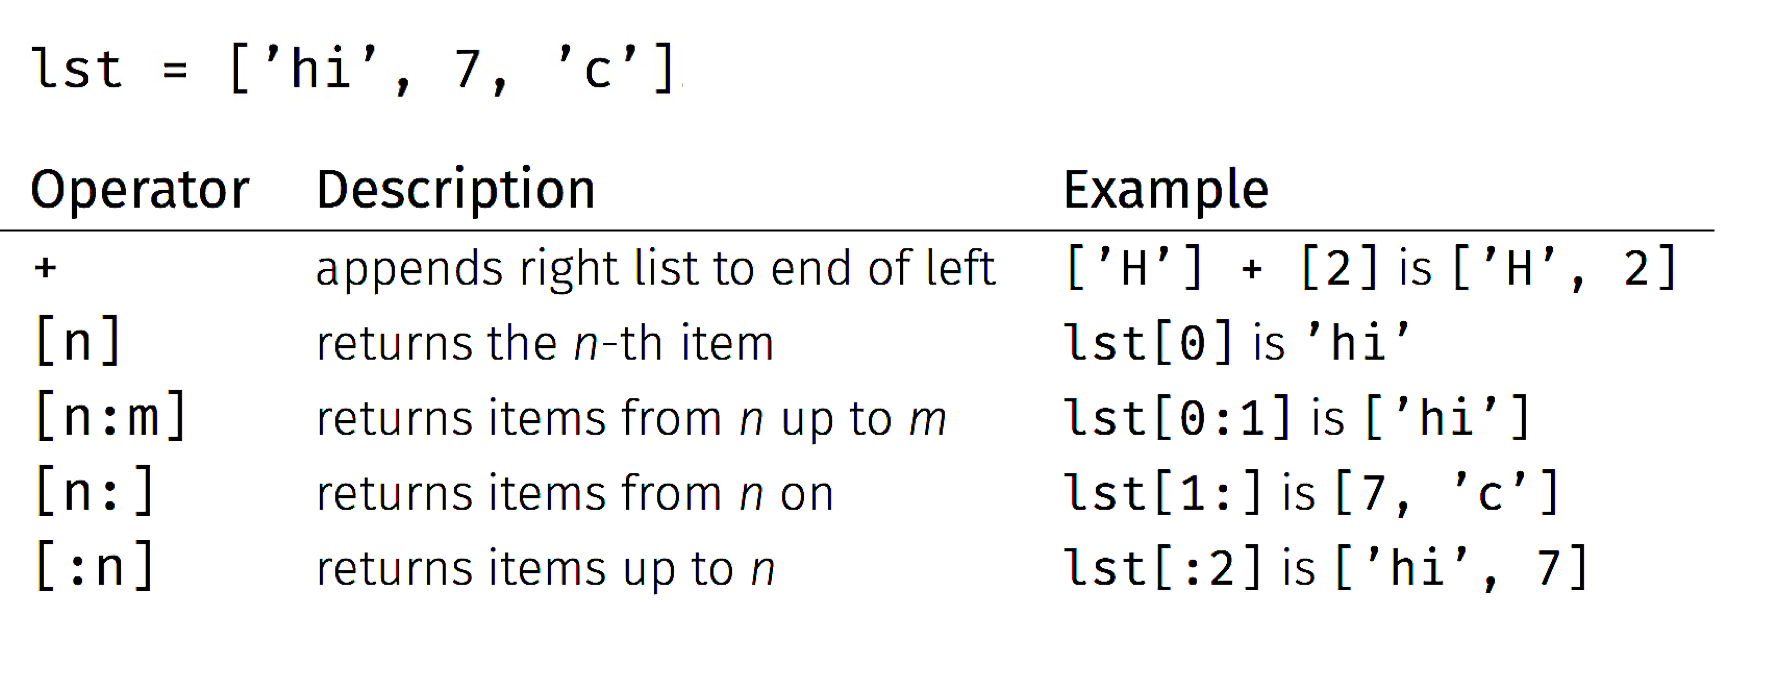

####Loops

You can loop over the elements of a list like this:

In [18]:
animals = ['cat', 'dog', 'monkey']
for animal in animals:
  print(animal)

cat
dog
monkey


If you want access to the index of each element within the body of a loop, use the built-in `enumerate` function:

In [19]:
animals = ['cat', 'dog', 'monkey']
for idx, animal in enumerate(animals):
  print('#{}: {}'.format(idx + 1, animal))

#1: cat
#2: dog
#3: monkey


####List comprehensions:

When programming, frequently we want to transform one type of data into another. As a simple example, consider the following code that computes square numbers:

In [20]:
nums = [0, 1, 2, 3, 4]
squares = []
for x in nums:
  squares.append(x ** 2)
print(squares)

[0, 1, 4, 9, 16]


You can make this code simpler using a list comprehension:

In [21]:
nums = [0, 1, 2, 3, 4]
squares = [x ** 2 for x in nums]
print(squares)

[0, 1, 4, 9, 16]


List comprehensions can also contain conditions:

In [22]:
nums = [0, 1, 2, 3, 4]
even_squares = [x ** 2 for x in nums if x % 2 == 0]
print(even_squares)

[0, 4, 16]


####Dictionaries

A dictionary stores (key, value) pairs, similar to a `Map` in Java or an object in Javascript. You can use it like this:

In [23]:
d = {'cat': 'cute', 'dog': 'furry'}  # Create a new dictionary with some data
print(d['cat'])       # Get an entry from a dictionary; prints "cute"
print('cat' in d)     # Check if a dictionary has a given key; prints "True"

cute
True


In [24]:
d['fish'] = 'wet'    # Set an entry in a dictionary
print(d['fish'])      # Prints "wet"

wet


In [25]:
print(d['monkey'])  # KeyError: 'monkey' not a key of d

KeyError: ignored

In [26]:
print(d.get('monkey', 'default_value'))  # Get an element with a default; prints "N/A"
print(d.get('fish', 'another default'))    # Get an element with a default; prints "wet"

default_value
wet


In [27]:
del d['fish']        # Remove an element from a dictionary
print(d.get('fish', 'N/A')) # "fish" is no longer a key; prints "N/A"

N/A


You can find all you need to know about dictionaries in the [documentation](https://docs.python.org/2/library/stdtypes.html#dict).

It is easy to iterate over the keys in a dictionary:

In [28]:
d = {'person': 2, 'cat': 4, 'spider': 8}
for animal, legs in d.items():
  print('A {} has {} legs'.format(animal, legs))

A person has 2 legs
A cat has 4 legs
A spider has 8 legs


Dictionary comprehensions: These are similar to list comprehensions, but allow you to easily construct dictionaries. For example:

In [29]:
nums = [0, 1, 2, 3, 4]
even_num_to_square = {x: x ** 2 for x in nums if x % 2 == 0}
print(even_num_to_square)

{0: 0, 2: 4, 4: 16}


####Sets

A set is an unordered collection of distinct elements. As a simple example, consider the following:

In [30]:
animals = {'cat', 'dog'}
print('cat' in animals)   # Check if an element is in a set; prints "True"
print('fish' in animals)  # prints "False"


True
False


In [31]:
animals.add('fish')      # Add an element to a set
print('fish' in animals)
print(len(animals))       # Number of elements in a set;

True
3


In [32]:
animals.add('cat')       # Adding an element that is already in the set does nothing
print(len(animals))
animals.remove('cat')    # Remove an element from a set
print(len(animals))

3
2


_Loops_: Iterating over a set has the same syntax as iterating over a list; however since sets are unordered, you cannot make assumptions about the order in which you visit the elements of the set:

In [33]:
animals = {'cat', 'dog', 'fish'}
for idx, animal in enumerate(animals):
    print('#{}: {}'.format(idx + 1, animal))

#1: cat
#2: dog
#3: fish


Set comprehensions: Like lists and dictionaries, we can easily construct sets using set comprehensions:

In [34]:
from math import sqrt
print({int(sqrt(x)) for x in range(30)})

{0, 1, 2, 3, 4, 5}


####Tuples

A tuple is an (immutable) ordered list of values. A tuple is in many ways similar to a list; one of the most important differences is that tuples can be used as keys in dictionaries and as elements of sets, while lists cannot. Here is a trivial example:

In [35]:
d = {(x, x + 1): x for x in range(10)}  # Create a dictionary with tuple keys
t = (5, 6)       # Create a tuple
print(type(t))
print(d[t])
print(d[(1, 2)])

<class 'tuple'>
5
1


In [36]:
t[0] = 1

TypeError: ignored

### Branches

Python supports the usual logical conditions from mathematics:

- Equals: a == b
- Not Equals: a != b
- Less than: a < b
- Less than or equal to: a <= b
- Greater than: a > b
- Greater than or equal to: a >= b
- These conditions can be used in several ways, most commonly in "if statements" and loops.

An "if statement" is written by using the if keyword.

In [37]:
a = 33
b = 200
if b > a:
  print("b is greater than a")

b is greater than a


Indentation

Python relies on indentation (whitespace at the beginning of a line) to define scope in the code. Other programming languages often use curly-brackets for this purpose.

In [38]:
a = 33
b = 200
if b > a:
print("b is greater than a") # you will get an error

IndentationError: ignored

The `elif` keyword is Python's way of saying "if the previous conditions were not true, then try this condition".

In [39]:
a = 33
b = 33
if b > a:
  print("b is greater than a")
elif a == b:
  print("a and b are equal")

a and b are equal


The `else` keyword catches anything which isn't caught by the preceding conditions.

In [40]:
a = 200
b = 33
if b > a:
  print("b is greater than a")
elif a == b:
  print("a and b are equal")
else:
  print("a is greater than b")

a is greater than b


###Functions

Python functions are defined using the `def` keyword. For example:

In [41]:
def sign(x):
    if x > 0:
        return 'positive'
    elif x < 0:
        return 'negative'
    else:
        return 'zero'

for x in [-1, 0, 1]:
    print(sign(x))

negative
zero
positive


We will often define functions to take optional keyword arguments, like this:

In [42]:
def hello(name, loud=False):
    if loud:
        print('HELLO, {}'.format(name.upper()))
    else:
        print('Hello, {}!'.format(name))

hello('Bob')
hello('Fred', loud=True)

Hello, Bob!
HELLO, FRED


###Classes

The syntax for defining classes in Python is straightforward:

In [43]:
class Greeter:

    # Constructor
    def __init__(self, name):
        self.name = name  # Create an instance variable

    # Instance method
    def greet(self, loud=False):
        if loud:
          print('HELLO, {}'.format(self.name.upper()))
        else:
          print('Hello, {}!'.format(self.name))

g = Greeter('Fred')  # Construct an instance of the Greeter class
g.greet()            # Call an instance method; prints "Hello, Fred"
g.greet(loud=True)   # Call an instance method; prints "HELLO, FRED!"

Hello, Fred!
HELLO, FRED


## Exercise

E1: Create a tuple called tup with the following seven objects:

- The first element is an integer of your choice
- The second element is a float of your choice
- The third element is the sum of the first two elements
- The fourth element is the difference of the first two elements
- The fifth element is first element divided by the second element
- Display the output of tup. What is the type of the variable tup?
- What happens if you try and chage an item in the tuple?

In [44]:
# your code here

E2: Write a python function to check if a number is an odd number.

In [45]:
# your code here

E3: With the function you created above, build a list that contains every even number between 1 and 100.

In [46]:
# your code here

E4: Create a dictionary, called ps_dict, that contains with the odd numbers less than 100 and their corresponding squares.

In [47]:
# your code here

E5: Create a dictionary, called ps_dict, that contains with the odd numbers less than 100 and their corresponding squares, but also skip the number that is lower than 80 and larger than 60.

## Reference & Credits:

The tutorial above is a combination of the code/instructions created by [here](https://harvard-iacs.github.io/2017-CS109A) - License: [MIT](https://github.com/Harvard-IACS/2020-CS109A/blob/master/LICENSE) and [here](https://cs231n.github.io/) - License: [MIT](https://github.com/cs231n/cs231n.github.io/blob/master/LICENSE).
Also the branch tutorial part is from [here](https://www.w3schools.com/python/python_conditions.asp)